# 18 — Análisis de una liga (Liga MX): plantillas, porteros, impacto en cancha y fantasy

Hay **un notebook por liga** (`18_analisis_liga_<liga>.ipynb`), todos con el mismo código: solo cambian el parámetro
`LIGA` (primera celda de código) y los textos de interpretación, que se escriben después de ver los resultados de
cada liga. Las figuras se guardan con el nombre de la liga en `output/figures/ligas/`, así que no se pisan. La misma
lógica alimenta la página web del análisis (`scripts/export_analisis_liga.py`).

**Datos**: el dataset unificado de la Fase 19 — tabla estándar + `playingtime` + `keepers` de FBref, 16 temporadas
(2010-11 a 2025-26). Se usa en dos niveles:

- **jugador-equipo-temporada** (`filas`) para todo lo que es de un *equipo*: si un jugador se fue a mitad de
  temporada, sus minutos cuentan para cada uno de sus dos equipos;
- **jugador-temporada** (`jt`) para todo lo que es de un *jugador*.

**Secciones**

1. **Plantillas y rotación** — cuántos jugadores usa cada equipo, qué tan concentrados están los minutos, edad y
   extranjeros, temporada por temporada.
2. **Porteros** — % de paradas, porterías a cero y goles recibidos, de la liga y de cada portero.
3. **Impacto en cancha** — ¿qué dicen el +/− y el "con/sin él" de un jugador? (solo desde 2014-15).
4. **Fantasy y dependencia** — cuánto depende cada equipo de su goleador y de su mejor jugador fantasy.

**Lo que conviene recordar al leer**: una celda vacía es "FBref no tiene el dato" (no cero). En esta liga-temporada
pueden faltar datos según la época — el diccionario `data/processed/jugadores_temporada_2010_2026_diccionario.csv`
dice desde cuándo existe cada columna. Toda la lógica está en `futbol_bd/liga.py` (probada en `tests/test_liga.py`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from futbol_bd import estilo, fantasy, liga, plantillas

# ======================================================================================================================
LIGA = "Liga MX"
# ======================================================================================================================

SLUG = LIGA.lower().replace(" ", "_")
FIGURAS = RAIZ / "output" / "figures" / "ligas"
FIGURAS.mkdir(parents=True, exist_ok=True)
estilo.aplicar()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

## 0. Los datos de la liga

Se construyen las dos tablas con las funciones del paquete (las mismas que generan el CSV unificado) y se agrega el
resumen por equipo-temporada (`liga.resumen_equipos`). Antes de analizar nada, un control de calidad: cada equipo debe
sumar ≈ partidos × 990 minutos (11 jugadores × 90 minutos por partido; un poco menos si hubo expulsiones). Si faltaran
jugadores en el scrapeo, este cociente quedaría claramente por debajo de 1.

In [2]:
filas = plantillas.unir_tablas_extra(plantillas.limpiar_panel(plantillas.cargar_panel_crudo()))
jt = fantasy.puntos_fantasy(plantillas.agregar_por_temporada(filas))
# Percentil fantasy dentro de liga-temporada-posición (900+ minutos), como en el notebook 17.
jt["pct_pts_jornada"] = fantasy.percentil_en_grupo(jt, "pts_por_jornada")
filas, jt = filas[filas["league"] == LIGA], jt[jt["league"] == LIGA]
equipos = liga.resumen_equipos(filas, LIGA)
TEMPORADAS = sorted(equipos["temporada_inicio"].unique())

control = equipos.assign(cobertura_minutos=equipos["minutos"] / (equipos["pj"] * 990)).groupby("season").agg(
    equipos=("team_id", "size"), partidos_por_equipo=("pj", "median"), jugadores=("jugadores_usados", "sum"),
    cobertura_minutos_min=("cobertura_minutos", "min"), cobertura_minutos_mediana=("cobertura_minutos", "median"))
print(f"{LIGA}: {len(jt):,} jugador-temporadas, {jt['id_jugador'].nunique():,} jugadores, "
      f"{equipos['team_id'].nunique()} equipos distintos en {len(TEMPORADAS)} temporadas")
control.round(3)

Liga MX: 8,511 jugador-temporadas, 2,569 jugadores, 27 equipos distintos en 16 temporadas


,equipos,partidos_por_equipo,jugadores,cobertura_minutos_min,cobertura_minutos_mediana
season,,,,,
2010-2011,18,34.0,523,0.991,0.994
2011-2012,18,34.0,523,0.991,0.994
2012-2013,18,34.0,560,0.991,0.996
2013-2014,18,34.0,567,0.971,0.995
2014-2015,18,34.0,547,0.989,0.996
2015-2016,18,34.0,563,0.993,0.996
2016-2017,18,34.0,561,0.993,0.996
2017-2018,18,34.0,546,0.992,0.995
2018-2019,18,34.0,573,0.990,0.994


Control superado: en todas las temporadas cada equipo suma entre el 97% y el 99.7% de los minutos teóricos (partidos ×
990); lo que falta son expulsiones. Hay 18 equipos y 34 partidos por equipo en todas las temporadas salvo 2019-20: 19
equipos y 28 partidos (el Clausura 2020 se canceló por COVID tras 10 jornadas, y Veracruz fue desafiliado después del
Apertura 2019, por eso jugó solo 18). En total, 8,511 jugador-temporadas de 2,569 jugadores en 27 clubes distintos
(una franquicia que cambia de sede aparece en FBref como club nuevo).

## 1. Plantillas y rotación

Cuatro medidas por equipo-temporada (definidas en `liga.resumen_equipos`):

- **jugadores usados**: cuántos jugadores tuvieron minutos;
- **jugadores para el 80% de los minutos**: concentración. Con un once fijo serían ~11-12; si el técnico rota, más.
  Es más robusta que "jugadores usados", que sube con cualquier debutante de 5 minutos;
- **edad ponderada por minutos**: la edad de *quien juega*, no la de la lista;
- **% de minutos de extranjeros** (nacionalidad deportiva según FBref, ver `liga.NACIONALES`).

La figura muestra, por temporada, la **mediana** de los equipos (línea) y el rango donde está la mitad central de los
equipos (banda, percentiles 25-75). Mediana y no promedio: un equipo con una temporada rara no mueve la tendencia.

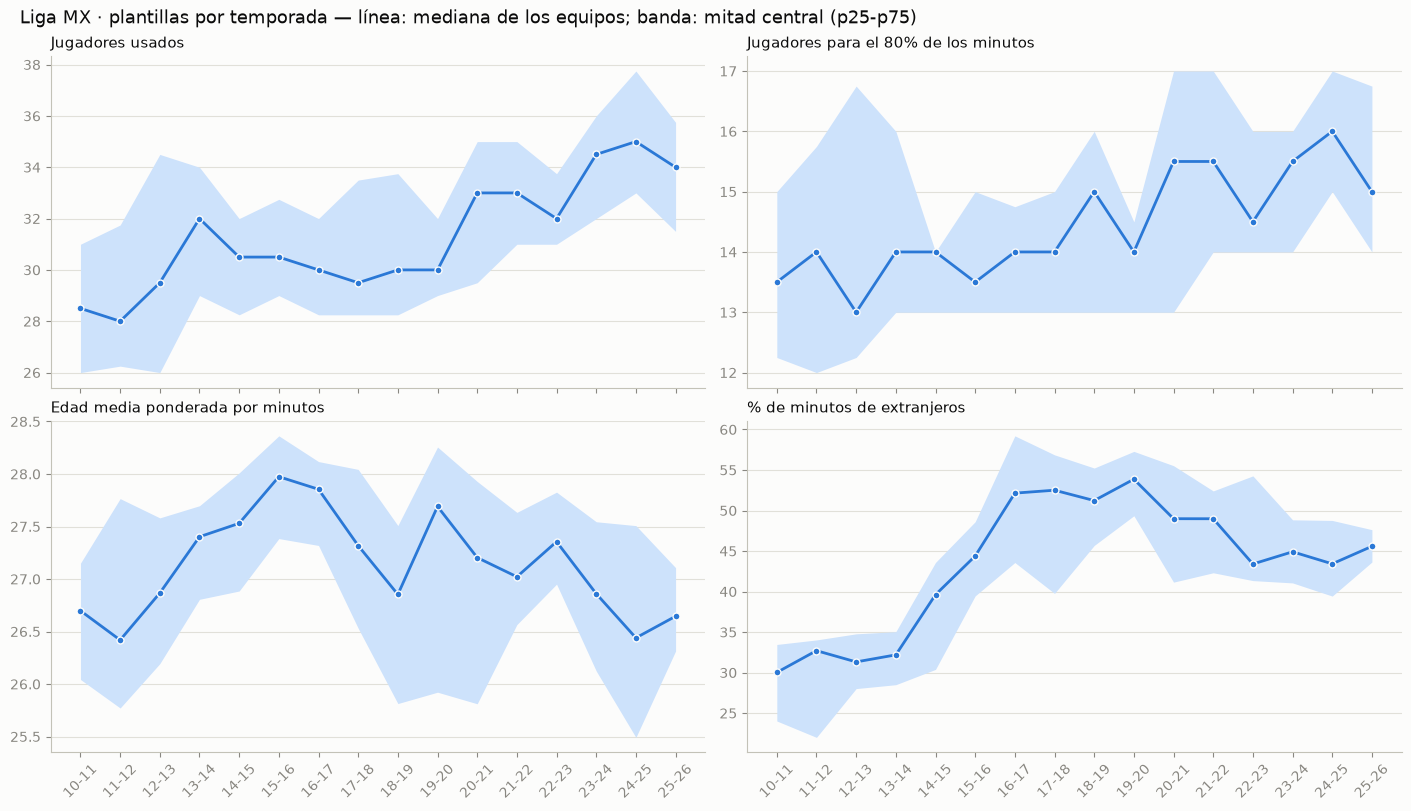

In [3]:
metricas = {"jugadores_usados": "Jugadores usados", "jugadores_80pct": "Jugadores para el 80% de los minutos",
            "edad_ponderada": "Edad media ponderada por minutos", "pct_min_extranjeros": "% de minutos de extranjeros"}
tendencia = liga.tendencia_liga(equipos, list(metricas))

fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True, constrained_layout=True)
for ax, (col, titulo) in zip(axs.ravel(), metricas.items()):
    ax.fill_between(TEMPORADAS, tendencia[("p25", col)], tendencia[("p75", col)], color=estilo.AZUL_CLARO, linewidth=0)
    ax.plot(TEMPORADAS, tendencia[("mediana", col)], color=estilo.AZUL, linewidth=2, marker="o", markersize=5,
            markeredgecolor=estilo.SUPERFICIE)
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
for ax in axs[1]:
    estilo.etiquetas_temporada(ax, TEMPORADAS)
fig.suptitle(f"{LIGA} · plantillas por temporada — línea: mediana de los equipos; banda: mitad central (p25-p75)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_plantillas.png", dpi=150)
plt.show()

Tres tendencias claras:

- **Se rota más.** La mediana de jugadores usados pasó de 28-30 (hasta 2019-20) a 33-35 (desde 2020-21), y los
  jugadores necesarios para el 80% de los minutos de 13-14 a 15-16. El salto coincide con la llegada de los cinco
  cambios por partido en 2020.
- **Extranjeros: subida y bajada.** Los minutos de extranjeros pasaron del 30-33% (2010-14) al 52% en 2016-17, con
  máximo de 54% en 2019-20, y bajaron al 43-46% desde 2022-23. Los saltos coinciden con cambios en el límite de
  extranjeros por plantilla, que la liga modificó varias veces en este periodo (el notebook no verifica cuáles).
- **Edad**: la edad de quien juega subió de 26.4 a 28.0 años (2015-16) y volvió a 26.4-26.6 en 2024-26.

In [4]:
# Los extremos de todo el periodo: los equipos que más rotaron (más jugadores para cubrir el 80% de los minutos) y los
# que menos. Se muestra también el resultado (puntos por partido) para ver si rotar se asocia con ganar o perder.
columnas = ["season", "equipo", "jugadores_usados", "jugadores_80pct", "edad_ponderada", "pct_min_extranjeros", "ppg"]
print("Más rotación:")
display(equipos.nlargest(6, "jugadores_80pct")[columnas].round(1))
print("Menos rotación:")
display(equipos.nsmallest(6, "jugadores_80pct")[columnas].round(1))
rho = spearmanr(equipos["jugadores_80pct"], equipos["ppg"], nan_policy="omit").statistic
print(f"Rotación vs puntos por partido (Spearman, todos los equipo-temporadas): {rho:.2f}")

Más rotación:


,season,equipo,jugadores_usados,jugadores_80pct,edad_ponderada,pct_min_extranjeros,ppg
112,2016-2017,Veracruz,42,22,28.1,53.2,1.0
40,2012-2013,San Luis,42,21,27.0,27.4,0.9
238,2023-2024,FC Juárez,41,21,27.5,43.6,1.0
49,2012-2013,Querétaro,46,20,26.6,27.6,0.9
93,2015-2016,Sinaloa,41,20,29.1,40.5,0.9
237,2023-2024,Pachuca,42,20,24.3,39.7,1.5


Menos rotación:


,season,equipo,jugadores_usados,jugadores_80pct,edad_ponderada,pct_min_extranjeros,ppg
2,2010-2011,América,29,11,27.1,31.4,1.6
6,2010-2011,Toluca,25,11,26.8,32.9,1.3
24,2011-2012,Toluca,25,11,28.4,33.2,1.2
29,2011-2012,Morelia,26,11,27.5,28.7,1.7
69,2013-2014,UANL,25,11,27.2,32.8,1.4
105,2015-2016,UANL,32,11,27.4,45.5,1.5


Rotación vs puntos por partido (Spearman, todos los equipo-temporadas): -0.47


Rotar se asocia fuerte con perder: la correlación entre jugadores para el 80% de los minutos y puntos por partido es
**−0.47**. Los seis equipo-temporadas que más rotaron (20-22 jugadores) sumaron 0.9-1.0 puntos por partido, con una
excepción: Pachuca 2023-24 (1.5), que además es la plantilla más joven de la lista (24.3 años). Los que menos rotaron
(11 jugadores) sumaron 1.2-1.7. La causa probablemente va en los dos sentidos: el equipo que pierde cambia técnico y
jugadores, y el que gana no tiene por qué tocar su once.

## 2. Porteros

Primero la liga completa: % de paradas (paradas / tiros a puerta recibidos), goles recibidos por partido y % de
partidos con portería a cero, sumando a todos los porteros antes de dividir (una tasa de la liga, no el promedio de
las tasas de cada portero). Después, cada portero en toda su carrera en la liga.

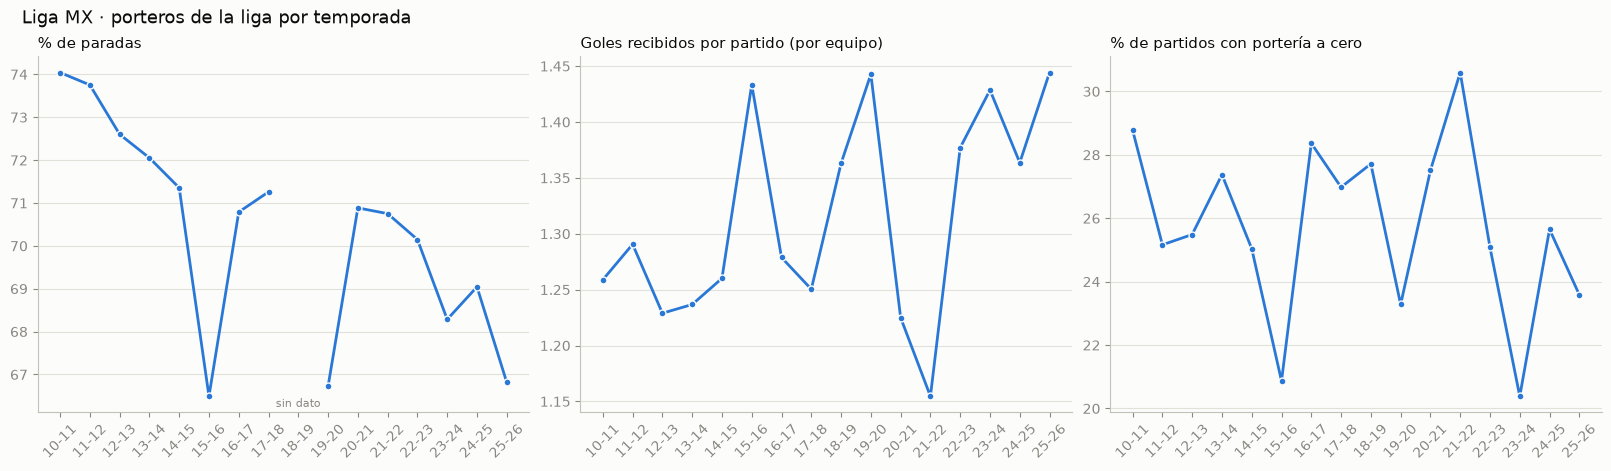

In [5]:
lp = liga.porteros_liga(jt, LIGA).reindex(TEMPORADAS)
paneles = {"pct_paradas": "% de paradas", "goles_recibidos_por_partido": "Goles recibidos por partido (por equipo)",
           "pct_porterias_cero": "% de partidos con portería a cero"}
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, constrained_layout=True)
for ax, (col, titulo) in zip(axs, paneles.items()):
    # Una temporada sin dato queda como hueco en la línea (no se une con la siguiente como si hubiera dato).
    ax.plot(TEMPORADAS, lp[col], color=estilo.AZUL, linewidth=2, marker="o", markersize=5,
            markeredgecolor=estilo.SUPERFICIE)
    faltan = [t for t in TEMPORADAS if pd.isna(lp.loc[t, col])]
    for t in faltan:
        ax.annotate("sin dato", (t, ax.get_ylim()[0]), xytext=(0, 4), textcoords="offset points", ha="center",
                    fontsize=8, color=estilo.TENUE)
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
    estilo.etiquetas_temporada(ax, TEMPORADAS)
fig.suptitle(f"{LIGA} · porteros de la liga por temporada", x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_porteros_liga.png", dpi=150)
plt.show()

- **El % de paradas de la liga cae**: de 74% en 2010-11 a 67% en 2025-26. En esta liga los porteros atajan menos
  tiros que hace 15 años, o los tiros a puerta son más difíciles, o FBref los cuenta distinto. Con estos datos no se
  puede separar (no hay calidad de tiro).
- **Los goles recibidos por partido suben un poco**: 1.23-1.29 hasta 2014-15 y 1.36-1.44 en 2022-26 (salvo el
  1.15-1.22 de 2020-22). Las temporadas recientes están entre las más goleadoras del periodo.
- **Porterías a cero**: entre el 20% y el 31% de los partidos, sin tendencia clara.
- 2018-19 no tiene paradas ni tiros a puerta en FBref: el hueco en la línea es a propósito, no un cero.

In [6]:
# Carreras completas en la liga (mínimo 9,000 minutos ≈ 100 partidos): el % de paradas de toda la carrera pondera cada
# temporada por los tiros que recibió.
carreras = liga.carrera_porteros(jt, LIGA, min_minutos=9000)
columnas = ["portero", "equipos", "desde", "hasta", "partidos", "pct_paradas", "pct_porterias_cero", "goles_recibidos_90"]
display(carreras[columnas].head(12).round(2))

# ¿El % de paradas es del portero o de su defensa? Correlación entre una temporada y la siguiente (1,500+ minutos).
porteros_jt = jt[jt["gk_games"].notna()]
r_paradas, n_paradas, _ = liga.estabilidad(porteros_jt, "gk_save_pct", minutos="gk_minutes")
r_cero, n_cero, _ = liga.estabilidad(porteros_jt, "gk_clean_sheets_pct", minutos="gk_minutes")
print(f"Estabilidad año a año — % de paradas: r = {r_paradas:.2f} ({n_paradas} pares); "
      f"% porterías a cero: r = {r_cero:.2f} ({n_cero} pares)")

,portero,equipos,desde,hasta,partidos,pct_paradas,pct_porterias_cero,goles_recibidos_90
id_jugador,,,,,,,,
d8f11068,Nahuel Guzmán,UANL,2014,2025,369.0,75.44,37.40,0.93
6568be59,Moisés Muñoz,Atlante / América / Chiapas / Puebla,2010,2017,232.0,75.34,30.60,1.17
775d365e,Esteban Andrada,Monterrey,2021,2024,112.0,75.12,36.61,0.95
d2dbfd8a,Oswaldo Sánchez,Santos Laguna,2010,2014,143.0,74.96,25.17,1.18
5c7fc905,Alfredo Talavera,Toluca / UNAM / FC Juárez,2010,2023,399.0,74.86,28.07,1.20
e9249cea,Óscar Pérez Rojas,Necaxa / San Luis / Pachuca,2010,2018,241.0,74.66,25.31,1.25
b18b798e,Enrique Palos,UANL / FC Juárez,2010,2020,124.0,73.95,36.29,1.06
e39a7e9c,José Corona,Cruz Azul / Tijuana,2010,2025,394.0,73.52,31.22,1.13
bb9e7a65,Miguel Pinto,Atlas,2010,2015,101.0,73.36,27.72,1.29


Estabilidad año a año — % de paradas: r = 0.30 (162 pares); % porterías a cero: r = 0.22 (187 pares)


**Nahuel Guzmán** (Tigres, 2014-2025) es el mejor portero del periodo en las tres métricas entre los 39 con 100+
partidos: 75.4% de paradas, 37.4% de porterías a cero y 0.93 goles recibidos por 90, sostenidos durante 369 partidos.

La estabilidad dice cuánto de cada número es del portero: el % de paradas tiene r = 0.30 entre temporadas (hay algo
del portero, con mucho ruido de temporada a temporada) y el % de porterías a cero r = 0.22 (depende más de la defensa).
Por eso el ranking de carrera, que junta muchas temporadas, es más confiable que el de un año.

In [7]:
# La última temporada, porteros con 900+ minutos. Y un control de calidad: goles recibidos según la tabla de porteros
# vs. goles recibidos por su equipo con él en cancha (onGA). Deberían coincidir; donde no, FBref se contradice.
ultima = jt[(jt["temporada_inicio"] == TEMPORADAS[-1]) & (jt["gk_minutes"] >= 900)]
display(ultima.sort_values("gk_save_pct", ascending=False)[
    ["player", "equipo_principal", "gk_games", "gk_save_pct", "gk_clean_sheets", "gk_goals_against",
     "on_goals_against"]].round(1))

por_temporada = liga.desacuerdo_goles_porteros(porteros_jt)
print(f"Porteros-temporada con ambos datos: {por_temporada['porteros'].sum()}; no coinciden: "
      f"{por_temporada['no_coinciden'].sum()}. Por temporada:")
display(por_temporada.set_index("temporada_inicio").T)
con_ambos = porteros_jt[porteros_jt["on_goals_against"].notna()]
difiere = con_ambos[con_ambos["gk_goals_against"] != con_ambos["on_goals_against"]]
print("Los de mayor diferencia:")
display(difiere.assign(diferencia=difiere["on_goals_against"] - difiere["gk_goals_against"])
        .reindex(columns=["player", "season", "equipo_principal", "gk_games", "gk_goals_against", "on_goals_against",
                          "diferencia"])
        .sort_values("diferencia", key=abs, ascending=False).head(5))

,player,equipo_principal,gk_games,gk_save_pct,gk_clean_sheets,gk_goals_against,on_goals_against
32713,Keylor Navas,UNAM,31.0,77.2,10.0,34.0,34.0
32738,Luis Manuel García,Toluca,17.0,77.0,5.0,14.0,14.0
32666,José Antonio Rodríguez,Tijuana,34.0,72.8,12.0,40.0,40.0
32770,Nahuel Guzmán,UANL,34.0,71.8,12.0,34.0,34.0
32579,Hugo González Durán,Toluca,18.0,70.6,7.0,20.0,20.0
32734,Luis Cárdenas,Monterrey,17.0,70.4,4.0,24.0,24.0
32675,José Hernández,Querétaro,13.0,69.4,3.0,15.0,15.0
32569,Guillermo Allison,Querétaro,22.0,69.0,6.0,35.0,35.0
32444,Carlos Moreno,Pachuca,33.0,68.5,6.0,40.0,40.0
32835,Rodolfo Cota,América,10.0,67.7,1.0,10.0,10.0


Porteros-temporada con ambos datos: 441; no coinciden: 85. Por temporada:


temporada_inicio,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
no_coinciden,23,23,9,8,6,2,6,1,0,4,2,1
porteros,35,38,36,34,37,31,42,38,37,36,41,36


Los de mayor diferencia:


,player,season,equipo_principal,gk_games,gk_goals_against,on_goals_against,diferencia
27484,Alfredo Talavera,2016-2017,Toluca,29.0,19.0,36.0,17.0
27007,Christian Martínez,2015-2016,León,16.0,21.0,31.0,10.0
27420,William Yarbrough,2015-2016,León,18.0,29.0,19.0,-10.0
26570,Federico Vilar,2014-2015,Atlas,33.0,47.0,38.0,-9.0
27472,Alejandro Palacios,2016-2017,UNAM,23.0,39.0,32.0,-7.0


En 2025-26 encabeza **Keylor Navas** (Pumas, 77.2% de paradas); el último con 900+ minutos es Sebastián Jurado
(Juárez, 59.5%).

**Calidad de datos**: en 85 de 441 porteros-temporada (19%) FBref da un número de goles recibidos en la tabla de
porteros y otro en la de minutos jugados. Pero casi todo está en **2014-15 y 2015-16** (23 de 35 y 23 de 38
porteros); desde 2019-20 coinciden casi siempre (0 a 6 casos por temporada). Para el fantasy defensivo: usar la
tabla de porteros como fuente y tomar con pinzas esas dos temporadas.

## 3. Impacto en cancha

FBref publica, desde 2014-15, dos medidas de "qué pasa cuando el jugador está en la cancha":

- **on-off** (`plus_minus_wowy`): goles netos de su equipo por 90 minutos con él en cancha, menos sin él;
- **puntos por partido con él** (`points_per_game`). Aquí se compara con los puntos por partido de su equipo en toda
  la temporada: `ppg_extra` = puntos con él − puntos del equipo (solo jugadores con un solo equipo esa temporada, para
  que la comparación sea limpia).

Son tentadoras como medida de "impacto", pero están muy expuestas a cosas ajenas al jugador: con quién comparte
cancha, contra quién jugó, si solo entra cuando el partido está roto. Antes de usarlas hay que probar si miden algo
**del jugador**: si fuera así, quien sale alto una temporada tendería a salir alto la siguiente. Como referencia de lo
que se ve cuando una medida sí es del jugador, se agrega una métrica individual: goles sin penal por 90 de los
delanteros.

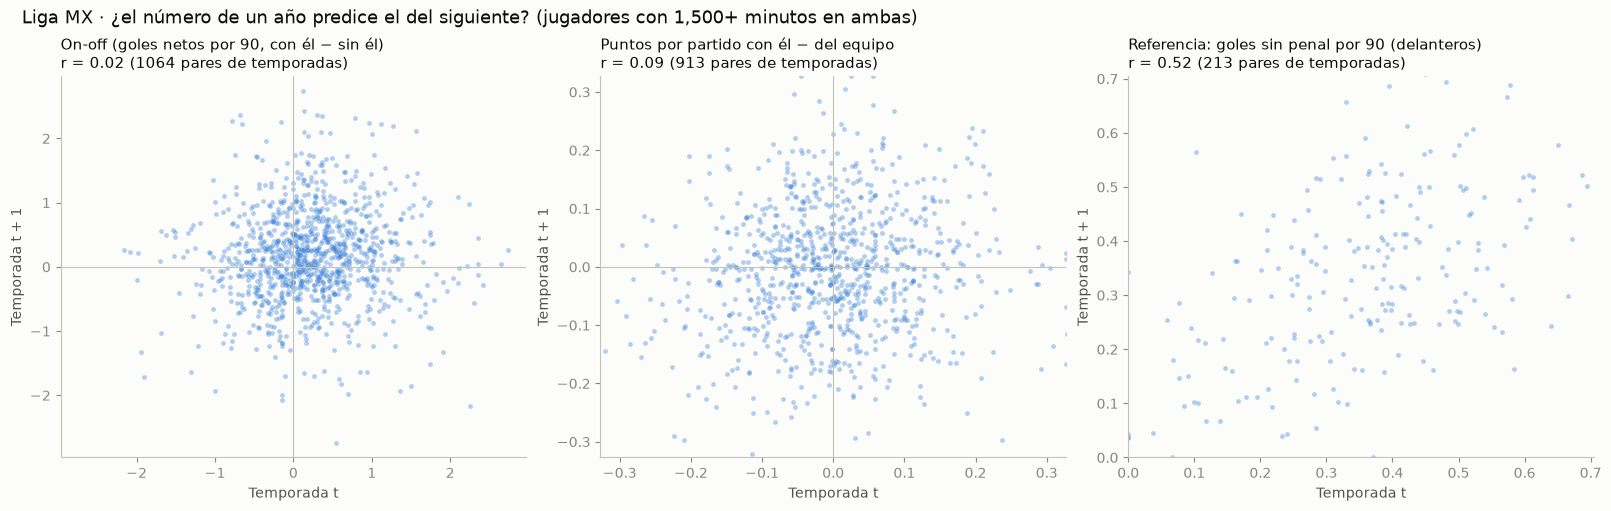

,r,pares
"On-off (goles netos por 90, con él − sin él)",0.02,1064.0
Puntos por partido con él − del equipo,0.09,913.0
Referencia: goles sin penal por 90 (delanteros),0.52,213.0


In [8]:
# ppg_extra = puntos por partido con él − del equipo; solo jugadores con un equipo en la temporada (ver docstring).
jt = liga.agregar_ppg_extra(jt, equipos)

pruebas = {
    "plus_minus_wowy": ("On-off (goles netos por 90, con él − sin él)", jt),
    "ppg_extra": ("Puntos por partido con él − del equipo", jt),
    "goals_pens_per90": ("Referencia: goles sin penal por 90 (delanteros)", jt[jt["pos_principal"] == "FW"]),
}
fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
resumen_estabilidad = {}
for ax, (col, (titulo, datos)) in zip(axs, pruebas.items()):
    r, n, pares = liga.estabilidad(datos, col, min_minutos=1500)
    resumen_estabilidad[titulo] = {"r": round(r, 2), "pares": n}
    ax.scatter(pares[col], pares[f"{col}_siguiente"], s=12, color=estilo.AZUL, alpha=0.35, linewidths=0)
    lim = np.nanpercentile(np.abs(pares[[col, f"{col}_siguiente"]].to_numpy()), 99)
    if col == "goals_pens_per90":
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    else:
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.axhline(0, color=estilo.EJE, linewidth=0.8); ax.axvline(0, color=estilo.EJE, linewidth=0.8)
    ax.set_title(f"{titulo}\nr = {r:.2f} ({n} pares de temporadas)")
    ax.set_xlabel("Temporada t"); ax.set_ylabel("Temporada t + 1")
fig.suptitle(f"{LIGA} · ¿el número de un año predice el del siguiente? (jugadores con 1,500+ minutos en ambas)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_impacto_estabilidad.png", dpi=150)
plt.show()
pd.DataFrame(resumen_estabilidad).T

El resultado es contundente:

| Medida | Correlación año a año |
|---|---|
| On-off (goles netos con él − sin él) | **0.02** (1,064 pares) |
| Puntos por partido con él − del equipo | **0.09** (913 pares) |
| Referencia: goles sin penal por 90 (delanteros) | **0.52** (213 pares) |

En la Liga MX, con totales de temporada, **el on-off y los puntos con/sin un jugador casi no dicen nada del jugador**:
el número de un año no predice el del siguiente, mientras que una medida individual sí (0.52). Una tabla de "mejores
on-off" de una temporada sería, sobre todo, una lista de afortunados; por eso aquí no se publica un ranking.

Qué haría falta para medir impacto en serio: los minutos que comparte cada jugador con cada compañero y rival,
partido a partido (alineaciones y cambios), para separar su efecto del de los demás (modelos tipo RAPM, del
básquetbol), juntando varias temporadas.

## 4. Fantasy y dependencia

Dos preguntas sobre cómo se reparte la producción dentro de cada equipo:

1. **Dependencia del goleador**: qué parte de los goles del equipo hizo su máximo goleador. ¿Depender de un solo
   jugador se asocia con sumar más o menos puntos?
2. **El mejor jugador fantasy de cada equipo** en la última temporada y qué parte de los puntos fantasy del equipo
   hizo (con el esquema ofensivo del notebook 17; los puntos de un jugador traspasado cuentan para su equipo
   principal).

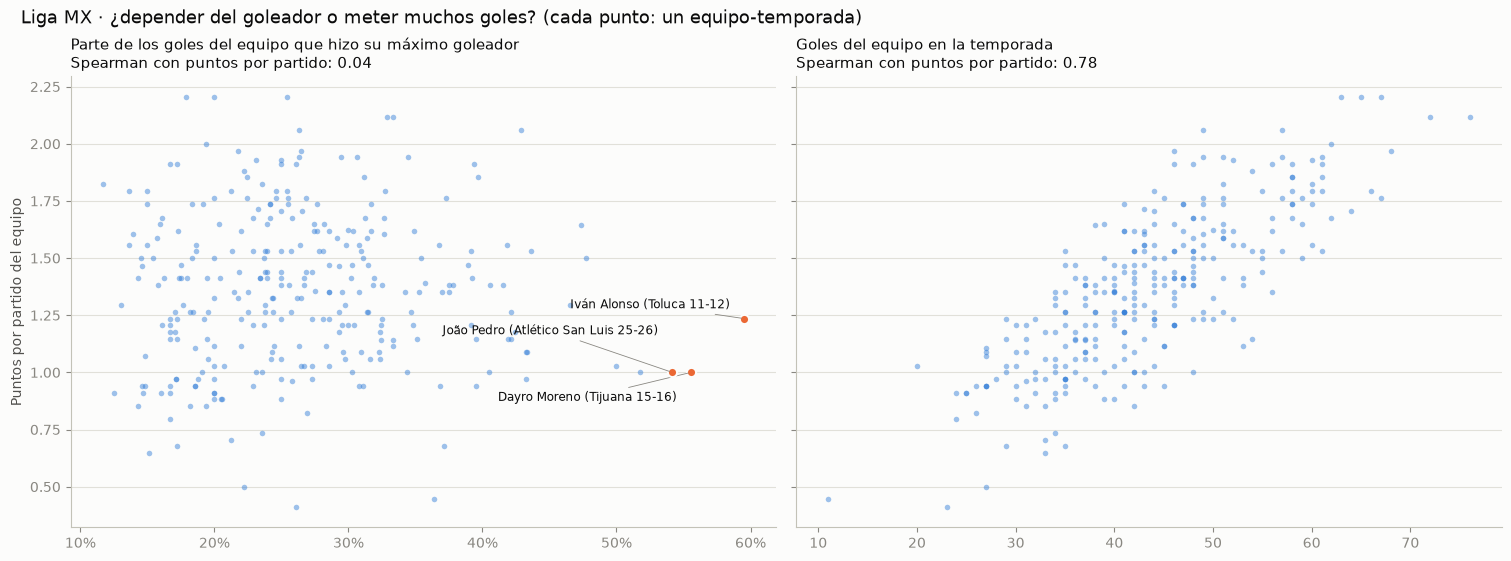

,season,equipo,goleador,goles_goleador,goles,dependencia_goleador,ppg
24,2011-2012,Toluca,Iván Alonso,25.0,42.0,0.60,1.24
101,2015-2016,Tijuana,Dayro Moreno,20.0,36.0,0.56,1.00
276,2025-2026,Atlético San Luis,João Pedro,26.0,48.0,0.54,1.00
184,2020-2021,FC Juárez,Dario Lezcano,15.0,29.0,0.52,1.00
80,2014-2015,UdeG,Fidel Martínez,10.0,20.0,0.50,1.03
88,2014-2015,Monterrey,Dorlan Pabón,21.0,44.0,0.48,1.50
178,2019-2020,UANL,André-Pierre Gignac,18.0,38.0,0.47,1.64
118,2016-2017,Morelia,Raúl Ruidíaz,20.0,43.0,0.47,1.29


Mediana de la dependencia por temporada: {'2010-2011': 0.25, '2011-2012': 0.29, '2012-2013': 0.25, '2013-2014': 0.26, '2014-2015': 0.25, '2015-2016': 0.25, '2016-2017': 0.27, '2017-2018': 0.32, '2018-2019': 0.26, '2019-2020': 0.28, '2020-2021': 0.3, '2021-2022': 0.19, '2022-2023': 0.23, '2023-2024': 0.2, '2024-2025': 0.23, '2025-2026': 0.24}


In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True, constrained_layout=True)
rho_dep = spearmanr(equipos["dependencia_goleador"], equipos["ppg"], nan_policy="omit").statistic
rho_gol = spearmanr(equipos["goles"], equipos["ppg"], nan_policy="omit").statistic
for ax, (col, titulo, rho, fmt) in zip(axs, [
        ("dependencia_goleador", "Parte de los goles del equipo que hizo su máximo goleador", rho_dep, "{:.0%}"),
        ("goles", "Goles del equipo en la temporada", rho_gol, "{:.0f}")]):
    ax.scatter(equipos[col], equipos["ppg"], s=16, color=estilo.AZUL, alpha=0.45, linewidths=0)
    ax.set_title(f"{titulo}\nSpearman con puntos por partido: {rho:.2f}")
    estilo.rejilla_y(ax)
    if col == "dependencia_goleador":
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
        # Se resaltan los 3 equipos más dependientes. Las etiquetas se escalonan en vertical porque dos de ellos tienen
        # exactamente 1.00 punto por partido y quedarían encimadas.
        for k, (_, e) in enumerate(equipos.nlargest(3, col).iterrows()):
            ax.scatter(e[col], e["ppg"], s=44, color=estilo.NARANJA, edgecolors=estilo.SUPERFICIE, linewidths=1.5,
                       zorder=3)
            nombre = e["goleador"] if len(e["goleador"]) <= 12 else e["goleador"].split()[-1]
            ax.annotate(f"{nombre} ({e['equipo']} {e['season'][2:4]}-{e['season'][7:]})", (e[col], e["ppg"]),
                        xytext=(-10, [10, -18, 30][k]), textcoords="offset points", ha="right", va="center",
                        fontsize=8.5, color=estilo.TINTA,
                        arrowprops=dict(arrowstyle="-", color=estilo.TENUE, linewidth=0.6))
axs[0].set_ylabel("Puntos por partido del equipo")
fig.suptitle(f"{LIGA} · ¿depender del goleador o meter muchos goles? (cada punto: un equipo-temporada)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_dependencia_goleador.png", dpi=150)
plt.show()

display(equipos.nlargest(8, "dependencia_goleador")[
    ["season", "equipo", "goleador", "goles_goleador", "goles", "dependencia_goleador", "ppg"]].round(2))
print("Mediana de la dependencia por temporada:",
      equipos.groupby("season")["dependencia_goleador"].median().round(2).to_dict())

- **Depender del goleador no se asocia con sumar puntos** (Spearman 0.04). Lo que sí se asocia es cuántos goles
  mete el equipo en total (0.78). Da igual quién los meta.
- Los más dependientes: **Iván Alonso** hizo el 60% de los goles del Toluca 2011-12, **Dayro Moreno** el 56% del
  Tijuana 2015-16 y **João Pedro** el 54% del Atlético San Luis 2025-26. Los tres equipos sumaron 1.0-1.24 puntos
  por partido: tener un goleador enorme no alcanzó.
- **Los goles están más repartidos que antes**: la mediana de la dependencia fue 25-32% hasta 2020-21 y 19-24%
  desde 2021-22.

In [10]:
# Mejor jugador fantasy de cada equipo en la última temporada y su parte de los puntos del equipo.
mejores = liga.mejor_fantasy_por_equipo(jt, TEMPORADAS[-1])
mejores[["equipo_principal", "player", "pos_principal", "goals", "assists", "pts_total", "pts_equipo",
         "parte_del_equipo", "pct_pts_jornada"]].round(2)

,equipo_principal,player,pos_principal,goals,assists,pts_total,pts_equipo,parte_del_equipo,pct_pts_jornada
32685,Atlético San Luis,João Pedro,FW,26.0,1.0,166.0,1103.0,0.15,100.00
32419,Guadalajara,Armando González,FW,24.0,2.0,161.0,1170.0,0.14,96.77
32915,UANL,Ángel Correa,MF,14.0,12.0,160.0,1235.0,0.13,100.00
32704,Tijuana,Kevin Castañeda,MF,12.0,6.0,138.0,1089.0,0.13,98.45
32681,Cruz Azul,José Paradela,MF,9.0,8.0,129.0,1136.0,0.11,96.90
32427,América,Brian Rodríguez,MF,13.0,6.0,137.0,1247.0,0.11,97.67
32591,León,Ismael Díaz,MF,10.0,6.0,117.0,1074.0,0.11,95.35
32880,Monterrey,Sergio Canales,MF,12.0,5.0,119.0,1128.0,0.11,96.12
32784,FC Juárez,Oscar Estupiñan,FW,14.0,2.0,112.0,1091.0,0.10,83.87
32801,Toluca,Paulinho,FW,18.0,4.0,130.0,1276.0,0.10,93.55


En 2025-26 el mejor jugador fantasy de cada equipo aporta entre el 7% (Bullaude, Santos) y el 15% (João Pedro, San
Luis) de los puntos fantasy de su equipo. Todos son delanteros o medios salvo **Facundo Almada** (Mazatlán, defensa,
percentil 100 de su posición): en el esquema ofensivo un gol de defensa vale 6. Cuando el fantasy incluya porterías a
cero, los defensas de los equipos sólidos van a subir en esta tabla.

## 5. Conclusiones y cómo ampliar a otra liga

**Liga MX, 2010-11 a 2025-26:**

1. **Plantillas**: los equipos rotan más que nunca (33-35 jugadores usados; 15-16 para el 80% de los minutos), con
   un salto en 2020. Los minutos de extranjeros pasaron del 30% al 54% (2019-20) y hoy rondan el 45%. Rotar mucho va
   de la mano con perder (−0.47).
2. **Porteros**: el % de paradas de la liga bajó de 74% a 67%. Nahuel Guzmán es el mejor del periodo en paradas,
   porterías a cero y goles recibidos. El % de paradas es en parte del portero (r = 0.30); las porterías a cero, más
   de la defensa.
3. **Impacto en cancha**: el on-off y los puntos con/sin un jugador de una temporada **no sirven** para evaluar
   individuos (r = 0.02 y 0.09 año a año). Medirlo exige datos partido a partido.
4. **Fantasy y dependencia**: lo que da puntos es que el equipo meta muchos goles, no de quién dependa. Los goles
   están hoy más repartidos que hace diez años.

**Otras ligas**: hay un notebook por liga (`18_analisis_liga_<liga>.ipynb`) con este mismo código; solo cambian
`LIGA` y los textos. La página web del análisis (`dashboard-predicciones/analisis.html`) muestra las mismas gráficas
para cada liga publicada, más un explorador de plantillas por equipo y temporada.

**Siguiente paso natural**: correr `liga.resumen_equipos` para las 7 ligas y compararlas en una sola figura (rotación,
extranjeros, dependencia, % de paradas lado a lado).